In [2]:
"""
exp01_gurobi_baseline — Experimento 1: Gurobi Baseline (Barrido Clásico Completo)

Pregunta: ¿Cómo escala Gurobi (formulación assignment) sobre los tres ejes de complejidad?
          ¿En qué N_vars la certificación óptima empieza a tardar?

Modelo: formulación assignment con x[j,t] ∈ {0,1} — buque j empieza en slot t.
  (1) Σ_t x[j,t] = 1                             — asignación única por buque
  (2) Σ_j Σ_{t': t'≤t<t'+p_j} x[j,t'] ≤ 1      — no solapamiento en pipeline
  (3) tard[j] ≥ Σ_t (t+p_j-d_j)·x[j,t]          — tardanza linealizada
Genera exactamente N_vars variables binarias, directamente comparables con QUBO.

Outputs:
  results/exp01_gurobi_baseline.xlsx
    hoja: raw_runs    (una fila por instancia × seed)
    hoja: metadata    (exp_version, run_uuid_last, timestamp)

Columnas: según docs/metrics.md §Experimento 1

Ejecución:
  Celda 1: SETUP
  Celda 2: LOAD instancias + verificación factibilidad
  Celda 3: RUN Gurobi — Eje 1 (Size_1–8)
  Celda 4: RUN Gurobi — Eje 2 (Cong_1–4)
  Celda 5: RUN Gurobi — Eje 3 (Struct_1–5)
  Celda 6: MILP-QUBO equivalencia
  Celda 7: PLOT tardanza óptima por eje
  Celda 8: PLOT wall_time por eje
"""

"\nexp01_gurobi_baseline — Experimento 1: Gurobi Baseline (Barrido Clásico Completo)\n\nPregunta: ¿Cómo escala Gurobi (formulación assignment) sobre los tres ejes de complejidad?\n          ¿En qué N_vars la certificación óptima empieza a tardar?\n\nModelo: formulación assignment con x[j,t] ∈ {0,1} — buque j empieza en slot t.\n  (1) Σ_t x[j,t] = 1                             — asignación única por buque\n  (2) Σ_j Σ_{t': t'≤t<t'+p_j} x[j,t'] ≤ 1      — no solapamiento en pipeline\n  (3) tard[j] ≥ Σ_t (t+p_j-d_j)·x[j,t]          — tardanza linealizada\nGenera exactamente N_vars variables binarias, directamente comparables con QUBO.\n\nOutputs:\n  results/exp01_gurobi_baseline.xlsx\n    hoja: raw_runs    (una fila por instancia × seed)\n    hoja: metadata    (exp_version, run_uuid_last, timestamp)\n\nColumnas: según docs/metrics.md §Experimento 1\n\nEjecución:\n  Celda 1: SETUP\n  Celda 2: LOAD instancias + verificación factibilidad\n  Celda 3: RUN Gurobi — Eje 1 (Size_1–8)\n  Celda 4: 

In [3]:
# CELDA 0: INSTALL — ejecutar una sola vez por sesión de Colab
# gurobipy requiere licencia WLS (configurar GRB_WLSACCESSID, GRB_WLSSECRET, GRB_LICENSEID en .env)
%pip install -q gurobipy dimod openpyxl seaborn

In [13]:
# CELDA 1: SETUP (Colab)
# ---- EDITAR SI TU CARPETA TIENE OTRO NOMBRE ---
DRIVE_TESIS_PATH = "MyDrive/TESIS"
# -----------------------------------------------

import os, sys, time, logging, datetime, subprocess
import importlib.util as _ilu
from pathlib import Path

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

DRIVE_TESIS      = f"/content/drive/{DRIVE_TESIS_PATH}"
REPO_ROOT        = Path(DRIVE_TESIS)
EXPERIMENTS2_DIR = REPO_ROOT / "experiments2"

for p in [str(REPO_ROOT / "src"), str(REPO_ROOT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Instalar dependencias si es necesario
_PKGS = [
    ("openpyxl", "openpyxl"),
    ("seaborn",  "seaborn"),
]
for _pip, _mod in _PKGS:
    if _ilu.find_spec(_mod) is None:
        print(f"  instalando {_pip}...", end=" ", flush=True)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pip],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        print("listo")
    else:
        print(f"  ok  {_pip}")

# Cargar credenciales desde TESIS/.env
# (GRB_WLSACCESSID, GRB_WLSSECRET, GRB_LICENSEID para Gurobi WLS)
_dotenv_path = REPO_ROOT / ".env"
if _dotenv_path.exists():
    for _ln in _dotenv_path.read_text().splitlines():
        _ln = _ln.strip()
        if _ln and not _ln.startswith("#") and "=" in _ln:
            _k, _, _v = _ln.partition("=")
            os.environ.setdefault(_k.strip(), _v.strip())
    print("  ok  credenciales cargadas desde TESIS/.env")
else:
    print("  AVISO: TESIS/.env no encontrado. Credenciales Gurobi no cargadas.")

import numpy as np
import pandas as pd

from config import DEFAULT_SEED, MACHINES

from experiments2.shared.run_id import new_run_uuid
from experiments2.shared.experiment_config import SEEDS, GUROBI_THREADS, GUROBI_TIMELIMIT_S
from experiments2.shared.io_utils import (
    ensure_directories,
    load_instances_from_excel,
    load_existing_runs,
    append_rows,
    save_metadata,
    load_metadata,
    INSTANCES_EXCEL,
    RESULTS_DIR,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")
logger = logging.getLogger("exp01")

ensure_directories()

RUN_UUID  = new_run_uuid()
FILEPATH  = RESULTS_DIR / "exp01_gurobi_baseline.xlsx"
SHEET     = "raw_runs"

logger.info("Exp 1 SETUP  run_uuid=%s", RUN_UUID)
logger.info("REPO_ROOT: %s", REPO_ROOT)
logger.info("Output: %s", FILEPATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ok  openpyxl
  ok  seaborn
  ok  credenciales cargadas desde TESIS/.env


In [14]:
# CELDA 2: LOAD instancias + verificación factibilidad pre-Gurobi
#
# TEST 1 — Capacidad bruta: Σp_j ≤ T
# TEST 2 — Ventanas individuales: d_j - r_j ≥ p_j para todo j
# TEST 3 — EDF greedy 1-máquina (Pinedo 2016, Thm 1.2)
#   Fundamento: EDF es óptimo para 1|r_j|Lmax.
#   Si EDF viola algún deadline, ninguna secuencia alternativa puede evitarlo.

if not INSTANCES_EXCEL.exists():
    raise FileNotFoundError(
        f"No se encontró {INSTANCES_EXCEL}. "
        "Ejecutar setup.py primero para generar las instancias."
    )

instances_by_axis: dict[str, dict] = {
    "size":       load_instances_from_excel("size"),
    "congestion": load_instances_from_excel("congestion"),
    "structure":  load_instances_from_excel("structure"),
}


def verify_feasibility(noms: pd.DataFrame, T: int) -> str:
    if int(noms["p_j"].sum()) > T:
        return "INFACTIBLE_CAPACIDAD"
    if ((noms["d_j"] - noms["r_j"]) < noms["p_j"]).any():
        return "INFACTIBLE_VENTANAS"
    jobs   = noms.sort_values("d_j").reset_index(drop=True)
    t_free = 0
    for _, job in jobs.iterrows():
        start  = max(t_free, int(job["r_j"]))
        if start + int(job["p_j"]) > int(job["d_j"]):
            return "TARDANZA_INEVITABLE"
        t_free = start + int(job["p_j"])
    return "FACTIBLE"


def _n_vars_qubo(noms: pd.DataFrame, T: int) -> int:
    """N_vars = Σ_j Σ_m |{t : t ≥ r_j  y  t + p_j ≤ T}| (sin blocked slots)."""
    total = 0
    for _, row in noms.iterrows():
        valid_slots = T - int(row["r_j"]) - int(row["p_j"]) + 1
        total += max(0, valid_slots) * len(MACHINES)
    return total


def _conflict_density(noms: pd.DataFrame) -> float:
    r = noms["r_j"].values
    d = noms["d_j"].values
    n = len(r)
    if n < 2:
        return 0.0
    total     = n * (n - 1) // 2
    conflicts = sum(
        1 for i in range(n) for j in range(i + 1, n)
        if r[i] < d[j] and r[j] < d[i]
    )
    return round(conflicts / total, 4)


print("\nVerificando factibilidad de instancias:")
feasibility_map: dict[str, str] = {}
for axis, axis_dict in instances_by_axis.items():
    for label, inst in axis_dict.items():
        status = verify_feasibility(inst["nominations"], inst["T"])
        feasibility_map[label] = status
        icon = "✓" if status in ("FACTIBLE", "TARDANZA_INEVITABLE") else "✗"
        print(f"  {icon}  {axis}/{label:<12} {status}")

truly_infeasible = [k for k, v in feasibility_map.items()
                    if v not in ("FACTIBLE", "TARDANZA_INEVITABLE")]
if truly_infeasible:
    raise AssertionError(
        f"Instancias infactibles detectadas — no enviar a Gurobi: {truly_infeasible}\n"
        "Regenerar instancias con setup.py."
    )
n_tardanza = sum(1 for v in feasibility_map.values() if v == "TARDANZA_INEVITABLE")
print(f"\nInstancias listas para Gurobi.")
print(f"  FACTIBLE:            {sum(1 for v in feasibility_map.values() if v == 'FACTIBLE')}")
print(f"  TARDANZA_INEVITABLE: {n_tardanza}  ← gradiente de comparación SA/LH")


Verificando factibilidad de instancias:
  ✓  size/Size_1       TARDANZA_INEVITABLE
  ✓  size/Size_2       TARDANZA_INEVITABLE
  ✓  size/Size_3       TARDANZA_INEVITABLE
  ✓  size/Size_4       TARDANZA_INEVITABLE
  ✓  size/Size_5       TARDANZA_INEVITABLE
  ✓  size/Size_6       TARDANZA_INEVITABLE
  ✓  size/Size_7       TARDANZA_INEVITABLE
  ✓  size/Size_8       TARDANZA_INEVITABLE
  ✓  congestion/Cong_1       TARDANZA_INEVITABLE
  ✓  congestion/Cong_2       TARDANZA_INEVITABLE
  ✓  congestion/Cong_3       TARDANZA_INEVITABLE
  ✓  congestion/Cong_4       TARDANZA_INEVITABLE
  ✓  structure/Struct_1     TARDANZA_INEVITABLE
  ✓  structure/Struct_2     TARDANZA_INEVITABLE
  ✓  structure/Struct_3     TARDANZA_INEVITABLE
  ✓  structure/Struct_4     TARDANZA_INEVITABLE
  ✓  structure/Struct_5     TARDANZA_INEVITABLE

Instancias listas para Gurobi.
  FACTIBLE:            0
  TARDANZA_INEVITABLE: 17  ← gradiente de comparación SA/LH


In [15]:
# CELDA 3: RUN Gurobi — Eje 1 (Size_1–5)
# 5 instancias × 5 seeds = 25 runs
# Append-safe: saltar (instance_label, seed) ya en el Excel

import traceback as _tb

def _solve_gurobi(inst: dict, seed: int, axis: str) -> dict:
    """
    Resuelve una instancia con Gurobi — formulación assignment.
    x[j,t] ∈ {0,1}: buque j empieza en slot t.
    Genera exactamente N_vars variables, comparables con QUBO.
    """
    import gurobipy as gp
    from gurobipy import GRB

    noms    = inst["nominations"].copy()
    T_inst  = int(inst["T"])
    vessels = list(noms["vessel_id"])
    r = {row["vessel_id"]: int(row["r_j"]) for _, row in noms.iterrows()}
    d = {row["vessel_id"]: int(row["d_j"]) for _, row in noms.iterrows()}
    p = {row["vessel_id"]: int(row["p_j"]) for _, row in noms.iterrows()}
    w = {row["vessel_id"]: float(row["w_j"]) for _, row in noms.iterrows()}

    # T_viable[j]: slots de inicio viables tras domain reduction
    T_viable: dict[str, list[int]] = {
        j: [t for t in range(r[j], T_inst - p[j] + 1)]
        for j in vessels
    }

    env = gp.Env(empty=True)
    env.setParam("OutputFlag", 0)
    # Cargar credenciales WLS desde .env si no están en el entorno del sistema
    _wls_id  = os.environ.get("GRB_WLSACCESSID")
    _wls_sec = os.environ.get("GRB_WLSSECRET")
    _wls_lic = os.environ.get("GRB_LICENSEID")
    if _wls_id:
        env.setParam("WLSAccessID", _wls_id)
    if _wls_sec:
        env.setParam("WLSSecret", _wls_sec)
    if _wls_lic:
        env.setParam("LicenseID", int(_wls_lic))
    env.start()

    model = gp.Model(env=env)
    model.Params.Threads   = GUROBI_THREADS
    model.Params.TimeLimit = GUROBI_TIMELIMIT_S
    model.Params.MIPGap    = 0.0
    model.Params.MIPGapAbs = 0.0
    model.Params.Seed      = seed

    # Variables de decisión: x[j,t] = 1 si j empieza en slot t
    x = {
        (j, t): model.addVar(vtype=GRB.BINARY, name=f"x_{j}_{t}")
        for j in vessels
        for t in T_viable[j]
    }
    tard = {j: model.addVar(lb=0.0, name=f"tard_{j}") for j in vessels}
    model.update()

    # (1) Cada buque se asigna a exactamente un slot de inicio
    for j in vessels:
        if T_viable[j]:
            model.addConstr(gp.quicksum(x[j, t] for t in T_viable[j]) == 1,
                            name=f"assign_{j}")

    # (2) No solapamiento en pipeline: en cada slot activo, como máximo 1 buque
    for t in range(T_inst):
        occupants = [
            x[j, t2]
            for j in vessels
            for t2 in T_viable[j]
            if t2 <= t < t2 + p[j]
        ]
        if len(occupants) > 1:
            model.addConstr(gp.quicksum(occupants) <= 1, name=f"pipe_{t}")

    # (3) Tardanza linealizada: tard[j] ≥ finish(j) - d[j]
    for j in vessels:
        if T_viable[j]:
            model.addConstr(
                tard[j] >= gp.quicksum((t2 + p[j] - d[j]) * x[j, t2]
                                       for t2 in T_viable[j]),
                name=f"tard_{j}",
            )

    model.setObjective(gp.quicksum(w[j] * tard[j] for j in vessels), GRB.MINIMIZE)

    t0 = time.perf_counter()
    model.optimize()
    wall_time = time.perf_counter() - t0

    status_map = {
        GRB.OPTIMAL:    "Optimal",
        GRB.TIME_LIMIT: "TimeLimit",
        GRB.INFEASIBLE: "Infeasible",
        GRB.MEM_LIMIT:  "OOM",
    }
    status   = status_map.get(model.Status, f"Unknown_{model.Status}")
    best_obj = model.ObjVal   if model.SolCount > 0 else float("inf")
    best_bnd = model.ObjBound if model.SolCount > 0 else float("nan")
    mip_gap  = model.MIPGap * 100.0 if model.SolCount > 0 else float("nan")
    n_nodes  = int(model.NodeCount)
    ttt      = bool(model.SolCount > 0 and mip_gap <= 5.0)

    model.dispose()
    env.dispose()

    return {
        "exp_id":           "exp01",
        "run_uuid":         RUN_UUID,
        "axis":             axis,
        "instance_label":   inst["instance_label"],
        "N":                inst["N"],
        "T":                T_inst,
        "rho_target":       inst.get("rho_target", float("nan")),
        "rho_effective":    inst.get("rho_effective", float("nan")),
        "mix_vlcc_pct":     inst.get("mix_vlcc_pct", float("nan")),
        "r_j_distribution": inst.get("r_j_distribution", "random"),
        "seed":             seed,
        "n_vars_qubo":      _n_vars_qubo(noms, T_inst),
        "conflict_density": _conflict_density(noms),
        "feasibility_pre":  feasibility_map.get(inst["instance_label"], "UNKNOWN"),
        "gurobi_status":    status,
        "best_obj":         best_obj,
        "best_bound":       best_bnd,
        "mip_gap_pct":      mip_gap,
        "wall_time_s":      round(wall_time, 3),
        "n_nodes_explored": n_nodes,
        "ttt_achieved":     ttt,
        "run_timestamp":    datetime.datetime.now().isoformat(),
    }


def run_axis(axis: str, labels_order: list[str]) -> None:
    """Corre Gurobi sobre todas las instancias del eje, append-safe."""
    existing = load_existing_runs(FILEPATH, SHEET)
    if not existing.empty:
        done = set(zip(existing["instance_label"], existing["seed"]))
    else:
        done = set()

    rows = []
    axis_dict = instances_by_axis[axis]
    for label in labels_order:
        inst = axis_dict.get(label)
        if inst is None:
            print(f"  WARNING: {label} no encontrada en eje {axis} — omitida")
            continue
        for seed in SEEDS:
            if (label, seed) in done:
                print(f"  skip {label} seed={seed} (ya completado)")
                continue

            print(f"  → {label} seed={seed} ...", flush=True)
            try:
                row = _solve_gurobi(inst, seed, axis)
            except Exception as exc:
                print(f"\n  *** ERROR {label} seed={seed}: {exc}")
                print(_tb.format_exc())
                row = {
                    "exp_id": "exp01", "run_uuid": RUN_UUID, "axis": axis,
                    "instance_label": label, "N": inst["N"], "T": inst["T"],
                    "rho_target": inst.get("rho_target", float("nan")),
                    "rho_effective": inst.get("rho_effective", float("nan")),
                    "mix_vlcc_pct": inst.get("mix_vlcc_pct", float("nan")),
                    "r_j_distribution": inst.get("r_j_distribution", "random"),
                    "seed": seed,
                    "n_vars_qubo": _n_vars_qubo(inst["nominations"], inst["T"]),
                    "conflict_density": _conflict_density(inst["nominations"]),
                    "feasibility_pre": feasibility_map.get(label, "UNKNOWN"),
                    "gurobi_status": "Error", "best_obj": float("inf"),
                    "best_bound": float("nan"), "mip_gap_pct": float("nan"),
                    "wall_time_s": 0.0, "n_nodes_explored": 0,
                    "ttt_achieved": False,
                    "run_timestamp": datetime.datetime.now().isoformat(),
                }

            rows.append(row)
            mip = row["mip_gap_pct"]
            print(f"    {row['gurobi_status']}  gap={mip:.1f}%  t={row['wall_time_s']:.1f}s"
                  if not (isinstance(mip, float) and np.isnan(mip))
                  else f"    {row['gurobi_status']}  t={row['wall_time_s']:.1f}s")

    if rows:
        append_rows(FILEPATH, SHEET, rows)
        print(f"Eje {axis}: {len(rows)} runs guardados.")
    else:
        print(f"Eje {axis}: nada nuevo para guardar.")


# Eje 1 — Size
run_axis("size", ["Size_1", "Size_2", "Size_3", "Size_4", "Size_5", "Size_6", "Size_7", "Size_8"])

  skip Size_1 seed=0 (ya completado)
  skip Size_1 seed=1 (ya completado)
  skip Size_1 seed=2 (ya completado)
  skip Size_1 seed=3 (ya completado)
  skip Size_1 seed=4 (ya completado)
  skip Size_2 seed=0 (ya completado)
  skip Size_2 seed=1 (ya completado)
  skip Size_2 seed=2 (ya completado)
  skip Size_2 seed=3 (ya completado)
  skip Size_2 seed=4 (ya completado)
  skip Size_3 seed=0 (ya completado)
  skip Size_3 seed=1 (ya completado)
  skip Size_3 seed=2 (ya completado)
  skip Size_3 seed=3 (ya completado)
  skip Size_3 seed=4 (ya completado)
  skip Size_4 seed=0 (ya completado)
  skip Size_4 seed=1 (ya completado)
  skip Size_4 seed=2 (ya completado)
  skip Size_4 seed=3 (ya completado)
  skip Size_4 seed=4 (ya completado)
  skip Size_5 seed=0 (ya completado)
  skip Size_5 seed=1 (ya completado)
  skip Size_5 seed=2 (ya completado)
  skip Size_5 seed=3 (ya completado)
  skip Size_5 seed=4 (ya completado)
  skip Size_6 seed=0 (ya completado)
  skip Size_6 seed=1 (ya completado)
 

In [7]:
# CELDA 4: RUN Gurobi — Eje 2 (Cong_1–4)
# T=62 fijo, N variable (6→12). Congestión emerge del volumen, no de clustering.

run_axis("congestion", ["Cong_1", "Cong_2", "Cong_3", "Cong_4"])

  skip Cong_1 seed=0 (ya completado)
  skip Cong_1 seed=1 (ya completado)
  skip Cong_1 seed=2 (ya completado)
  skip Cong_1 seed=3 (ya completado)
  skip Cong_1 seed=4 (ya completado)
  skip Cong_2 seed=0 (ya completado)
  skip Cong_2 seed=1 (ya completado)
  skip Cong_2 seed=2 (ya completado)
  skip Cong_2 seed=3 (ya completado)
  skip Cong_2 seed=4 (ya completado)
  skip Cong_3 seed=0 (ya completado)
  skip Cong_3 seed=1 (ya completado)
  skip Cong_3 seed=2 (ya completado)
  skip Cong_3 seed=3 (ya completado)
  skip Cong_3 seed=4 (ya completado)
  skip Cong_4 seed=0 (ya completado)
  skip Cong_4 seed=1 (ya completado)
  skip Cong_4 seed=2 (ya completado)
  skip Cong_4 seed=3 (ya completado)
  skip Cong_4 seed=4 (ya completado)
Eje congestion: nada nuevo para guardar.


In [8]:
# CELDA 5: RUN Gurobi — Eje 3 (Struct_1–5)
# N=10, T=62, distribución variable. Geometría del landscape.

run_axis("structure", ["Struct_1", "Struct_2", "Struct_3", "Struct_4", "Struct_5"])

# Guardar metadata
save_metadata(FILEPATH, {
    "exp_version":        "v11.3",
    "run_uuid_last":      RUN_UUID,
    "timestamp":          datetime.datetime.now().isoformat(),
    "gurobi_timelimit_s": GUROBI_TIMELIMIT_S,
    "gurobi_threads":     GUROBI_THREADS,
    "n_seeds":            len(SEEDS),
})
logger.info("Exp 1 MILP completo. Resultados: %s", FILEPATH)

  skip Struct_1 seed=0 (ya completado)
  skip Struct_1 seed=1 (ya completado)
  skip Struct_1 seed=2 (ya completado)
  skip Struct_1 seed=3 (ya completado)
  skip Struct_1 seed=4 (ya completado)
  skip Struct_2 seed=0 (ya completado)
  skip Struct_2 seed=1 (ya completado)
  skip Struct_2 seed=2 (ya completado)
  skip Struct_2 seed=3 (ya completado)
  skip Struct_2 seed=4 (ya completado)
  skip Struct_3 seed=0 (ya completado)
  skip Struct_3 seed=1 (ya completado)
  skip Struct_3 seed=2 (ya completado)
  skip Struct_3 seed=3 (ya completado)
  skip Struct_3 seed=4 (ya completado)
  skip Struct_4 seed=0 (ya completado)
  skip Struct_4 seed=1 (ya completado)
  skip Struct_4 seed=2 (ya completado)
  skip Struct_4 seed=3 (ya completado)
  skip Struct_4 seed=4 (ya completado)
  skip Struct_5 seed=0 (ya completado)
  skip Struct_5 seed=1 (ya completado)
  skip Struct_5 seed=2 (ya completado)
  skip Struct_5 seed=3 (ya completado)
  skip Struct_5 seed=4 (ya completado)
Eje structure: nada nuevo

In [ ]:
# CELDA 6: MILP-QUBO EQUIVALENCIA
#
# Para cada instancia donde Gurobi MILP certificó óptimo, resolver también el QUBO
# como BQP binario con Gurobi y comparar el objetivo de scheduling.
# Hoja nueva: milp_qubo_equiv
#
# 2 workers en paralelo (= vCPUs de Colab Free). Cada worker usa Threads=1 en Gurobi,
# así los 2 cores trabajan simultáneamente sin contención. Gurobi libera el GIL
# durante optimize(), por lo que ThreadPoolExecutor es suficiente.
# Cada resultado se guarda al instante (lock para serializar escritura al Excel).

SHEET_EQUIV = "milp_qubo_equiv"

import gc
import threading
import concurrent.futures

_xlsx_lock = threading.Lock()

from config import PENALTY_ALPHA as _CFG_ALPHA, PENALTY_BETA as _CFG_BETA
from preprocessing import compute_feasible_slots
from qubo_builder import build_qubo

_EXP2_META_PATH = RESULTS_DIR / "exp02_lagrange_calibration.xlsx"
try:
    if _EXP2_META_PATH.exists():
        _meta2_equiv = load_metadata(_EXP2_META_PATH)
        _alpha_equiv = float(_meta2_equiv.get("alpha_star", _CFG_ALPHA))
        _beta_equiv  = float(_meta2_equiv.get("beta_star",  _CFG_BETA))
    else:
        _alpha_equiv, _beta_equiv = _CFG_ALPHA, _CFG_BETA
except Exception:
    _alpha_equiv, _beta_equiv = _CFG_ALPHA, _CFG_BETA
logger.info("MILP-QUBO equiv: α=%.1f β=%.1f", _alpha_equiv, _beta_equiv)


def _solve_gurobi_bqp(
    inst: dict,
    axis: str,
    label: str,
    alpha: float,
    beta: float,
    milp_obj: float,
    milp_n_vars: int,
    milp_wall_time: float,
) -> dict:
    """Resuelve el QUBO como MIP linealizado con Gurobi.

    El producto binario x_i*x_j se reemplaza por una variable auxiliar z_ij con
    restricciones McCormick (exactas para binarias):
        z ≤ x_i,  z ≤ x_j,  z ≥ x_i + x_j - 1
    Esto convierte el BQP no-convexo en un MIP lineal que Gurobi resuelve
    órdenes de magnitud más rápido.
    """
    import gurobipy as gp
    from gurobipy import GRB
    from solver import decode_schedule, check_feasibility

    noms   = inst["nominations"].copy()
    T_inst = int(inst["T"])
    vdf    = compute_feasible_slots(noms, horizon_slots=T_inst)
    bqm, _, _, _, _ = build_qubo(vdf, alpha=alpha, beta=beta)

    var_list    = list(bqm.variables)
    n_vars_qubo = len(var_list)
    var_idx     = {v: i for i, v in enumerate(var_list)}

    env = gp.Env(empty=True)
    env.setParam("OutputFlag", 0)
    _wls_id  = os.environ.get("GRB_WLSACCESSID")
    _wls_sec = os.environ.get("GRB_WLSSECRET")
    _wls_lic = os.environ.get("GRB_LICENSEID")
    if _wls_id:  env.setParam("WLSAccessID", _wls_id)
    if _wls_sec: env.setParam("WLSSecret", _wls_sec)
    if _wls_lic: env.setParam("LicenseID", int(_wls_lic))
    env.start()

    model = gp.Model(env=env)
    model.Params.Threads    = GUROBI_THREADS
    model.Params.TimeLimit  = 3600  # 1 h por instancia
    model.Params.MIPGap     = 0.0
    model.Params.Seed       = 0

    x_bqp = [model.addVar(vtype=GRB.BINARY, name=f"x{i}") for i in range(n_vars_qubo)]
    model.update()

    # Objetivo lineal — términos de primer orden
    obj = gp.LinExpr()
    for v, bias in bqm.linear.items():
        obj.add(x_bqp[var_idx[v]], float(bias))

    # Linealizar términos cuadráticos: z_ij = x_i * x_j (McCormick exacto para binarias)
    for (v1, v2), bias in bqm.quadratic.items():
        i, j = var_idx[v1], var_idx[v2]
        xi, xj = x_bqp[i], x_bqp[j]
        z = model.addVar(vtype=GRB.BINARY, name=f"z{i}_{j}")
        model.addConstr(z <= xi)
        model.addConstr(z <= xj)
        model.addConstr(z >= xi + xj - 1)
        obj.add(z, float(bias))

    # Liberar BQM — ya no se necesita
    del bqm
    gc.collect()

    model.setObjective(obj, GRB.MINIMIZE)
    del obj
    model.update()

    t0_bqp = time.perf_counter()
    model.optimize()
    qubo_wall = time.perf_counter() - t0_bqp

    status_map_bqp = {
        GRB.OPTIMAL:    "Optimal",
        GRB.TIME_LIMIT: "TimeLimit",
        GRB.INFEASIBLE: "Infeasible",
    }
    gurobi_bqp_status = status_map_bqp.get(model.Status, f"Unknown_{model.Status}")

    # Capturar bound y gap antes de dispose
    try:
        best_bound_bqp = float(model.ObjBound)
    except Exception:
        best_bound_bqp = float("nan")
    try:
        mip_gap_bqp = float(model.MIPGap) * 100.0  # → porcentaje
    except Exception:
        mip_gap_bqp = float("nan")

    qubo_gurobi_obj = float("nan")
    is_feasible_bqp = False
    if model.SolCount > 0:
        best_sample_bqp = {v: round(x_bqp[var_idx[v]].X) for v in var_list}
        del x_bqp
        sched_bqp = decode_schedule(best_sample_bqp, vdf)
        fres_bqp  = check_feasibility(sched_bqp, vdf)
        is_feasible_bqp = bool(fres_bqp["is_feasible"])
        if is_feasible_bqp:
            qubo_gurobi_obj = float(fres_bqp["total_weighted_tardiness"])
    else:
        del x_bqp

    model.dispose()
    env.dispose()
    gc.collect()

    match = (
        gurobi_bqp_status == "Optimal"
        and not np.isnan(qubo_gurobi_obj)
        and not np.isnan(milp_obj)
        and abs(qubo_gurobi_obj - milp_obj) <= 1e-4
    )

    return {
        "exp_id":            "exp01",
        "run_uuid":          RUN_UUID,
        "axis":              axis,
        "instance_label":    label,
        "milp_obj":          milp_obj,
        "qubo_gurobi_obj":   qubo_gurobi_obj,
        "qubo_best_bound":   best_bound_bqp,
        "qubo_mip_gap_pct":  round(mip_gap_bqp, 4) if not np.isnan(mip_gap_bqp) else float("nan"),
        "match":             match,
        "milp_n_vars":       milp_n_vars,
        "qubo_n_vars":       n_vars_qubo,
        "milp_wall_time_s":  round(milp_wall_time, 3),
        "qubo_wall_time_s":  round(qubo_wall, 3),
        "gurobi_bqp_status": gurobi_bqp_status,
        "is_feasible_bqp":   is_feasible_bqp,
        "alpha":             _alpha_equiv,
        "beta":              _beta_equiv,
        "run_timestamp":     datetime.datetime.now().isoformat(),
    }


_df_base_equiv = load_existing_runs(FILEPATH, SHEET)
if _df_base_equiv.empty:
    logger.warning("MILP-QUBO equiv: raw_runs vacío — ejecutar run_axis primero.")
else:
    _optimal_milp = (
        _df_base_equiv[_df_base_equiv["gurobi_status"] == "Optimal"]
        .groupby("instance_label", sort=True)
        .agg(
            best_obj    =("best_obj",    "mean"),
            wall_time_s =("wall_time_s", "mean"),
            n_vars_qubo =("n_vars_qubo", "first"),
            axis_name   =("axis",        "first"),
        )
        .reset_index()
        .rename(columns={"axis_name": "axis"})
    )

    _existing_equiv = load_existing_runs(FILEPATH, SHEET_EQUIV)
    _done_equiv = (
        set(_existing_equiv["instance_label"].tolist())
        if not _existing_equiv.empty else set()
    )

    _pending_equiv: list[tuple] = []
    for _, _row_ref in _optimal_milp.iterrows():
        _lbl = str(_row_ref["instance_label"])
        if _lbl in _done_equiv:
            logger.info("  skip equiv %s (ya completado)", _lbl)
            continue
        _ax   = str(_row_ref["axis"])
        _inst = instances_by_axis.get(_ax, {}).get(_lbl)
        if _inst is None:
            logger.warning("  equiv %s no encontrada en eje %s — omitida", _lbl, _ax)
            continue
        _pending_equiv.append((
            _inst, _ax, _lbl,
            float(_row_ref["best_obj"]),
            int(_row_ref["n_vars_qubo"]),
            float(_row_ref["wall_time_s"]),
        ))

    # Ordenar de menor a mayor n_vars_qubo: resultados rápidos primero,
    # y si Colab interrumpe el append-safe retoma desde donde quedó.
    _pending_equiv.sort(key=lambda t: t[4])

    if not _pending_equiv:
        logger.info("MILP-QUBO equiv: nada pendiente.")
    else:
        _N_WORKERS = min(len(_pending_equiv), 2)  # Colab Free = 2 vCPUs
        logger.info("MILP-QUBO equiv: %d instancias — %d workers en paralelo",
                    len(_pending_equiv), _N_WORKERS)
        _n_saved = 0

        def _run_and_save(args):
            _inst, _ax, _lbl, _obj, _nvars, _wt = args
            row = _solve_gurobi_bqp(
                _inst, _ax, _lbl,
                alpha=_alpha_equiv, beta=_beta_equiv,
                milp_obj=_obj, milp_n_vars=_nvars, milp_wall_time=_wt,
            )
            with _xlsx_lock:
                append_rows(FILEPATH, SHEET_EQUIV, [row])
            return row

        with concurrent.futures.ThreadPoolExecutor(max_workers=_N_WORKERS) as _pool:
            _futs = {_pool.submit(_run_and_save, args): args[2] for args in _pending_equiv}
            for _fut in concurrent.futures.as_completed(_futs):
                _lbl = _futs[_fut]
                try:
                    _row_equiv = _fut.result()
                    _n_saved += 1
                    logger.info(
                        "    [done] %s  match=%s  milp=%.2f  qubo=%.2f  t=%.2fs  status=%s",
                        _lbl,
                        _row_equiv["match"],
                        _row_equiv["milp_obj"],
                        _row_equiv["qubo_gurobi_obj"] if not np.isnan(_row_equiv["qubo_gurobi_obj"]) else -1,
                        _row_equiv["qubo_wall_time_s"],
                        _row_equiv["gurobi_bqp_status"],
                    )
                except Exception as exc:
                    logger.error("  equiv %s falló: %s", _lbl, exc)
                finally:
                    gc.collect()

        logger.info("MILP-QUBO equiv: %d/%d instancias guardadas en hoja %s",
                    _n_saved, len(_pending_equiv), SHEET_EQUIV)


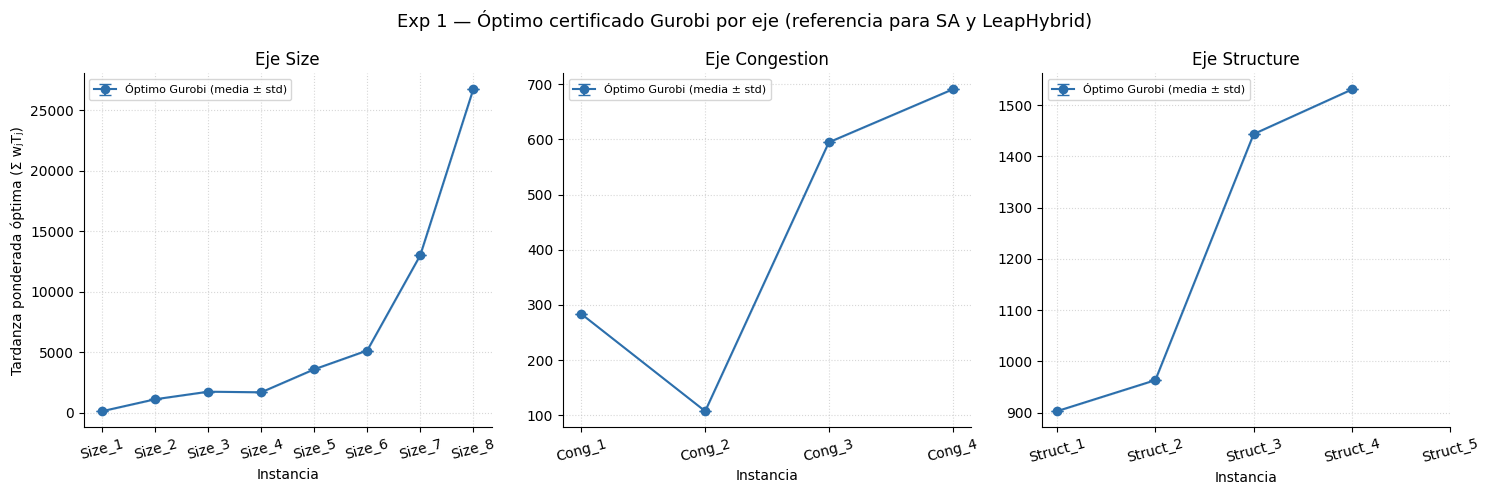

In [16]:
# CELDA 7: PLOT tardanza óptima (best_obj) por eje
# Este es el resultado principal del Exp 1: el óptimo certificado que SA y LH deben igualar.

import gc
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(
    FILEPATH, sheet_name=SHEET,
    usecols=["axis", "instance_label", "best_obj"],
)

axis_order = {
    "size":       ["Size_1", "Size_2", "Size_3", "Size_4", "Size_5", "Size_6", "Size_7", "Size_8"],
    "congestion": ["Cong_1", "Cong_2", "Cong_3", "Cong_4"],
    "structure":  ["Struct_1", "Struct_2", "Struct_3", "Struct_4", "Struct_5"],
}

fig, axes_plot = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax_plot, (axis_name, labels) in zip(axes_plot, axis_order.items()):
    sub = df[df["axis"] == axis_name].copy()
    sub["instance_label"] = pd.Categorical(sub["instance_label"], categories=labels, ordered=True)
    agg = (sub.groupby("instance_label", observed=True)["best_obj"]
              .agg(["mean", "std"]).reset_index()
              .rename(columns={"mean": "obj_mean", "std": "obj_std"}))

    ax_plot.errorbar(range(len(agg)), agg["obj_mean"], yerr=agg["obj_std"].fillna(0),
                     fmt="o-", capsize=4, color="#2C6FAC", label="Óptimo Gurobi (media ± std)")
    ax_plot.fill_between(range(len(agg)),
                         (agg["obj_mean"] - agg["obj_std"].fillna(0)).clip(lower=0),
                         agg["obj_mean"] + agg["obj_std"].fillna(0),
                         alpha=0.15, color="#2C6FAC")
    ax_plot.set_xticks(range(len(labels)))
    ax_plot.set_xticklabels(labels, rotation=15)
    ax_plot.set_xlabel("Instancia")
    ax_plot.set_ylabel("Tardanza ponderada óptima (Σ wⱼTⱼ)" if axis_name == "size" else "")
    ax_plot.set_title(f"Eje {axis_name.capitalize()}")
    ax_plot.legend(fontsize=8)
    ax_plot.grid(True, linestyle=":", alpha=0.5)
    sns.despine(ax=ax_plot)

fig.suptitle("Exp 1 — Óptimo certificado Gurobi por eje (referencia para SA y LeapHybrid)",
             fontsize=13)
plt.tight_layout()
plot_path = RESULTS_DIR / "exp01_optimal_obj.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
del fig, axes_plot, df, sub, agg
gc.collect()
logger.info("Guardado: %s", plot_path)

NameError: name 'df' is not defined

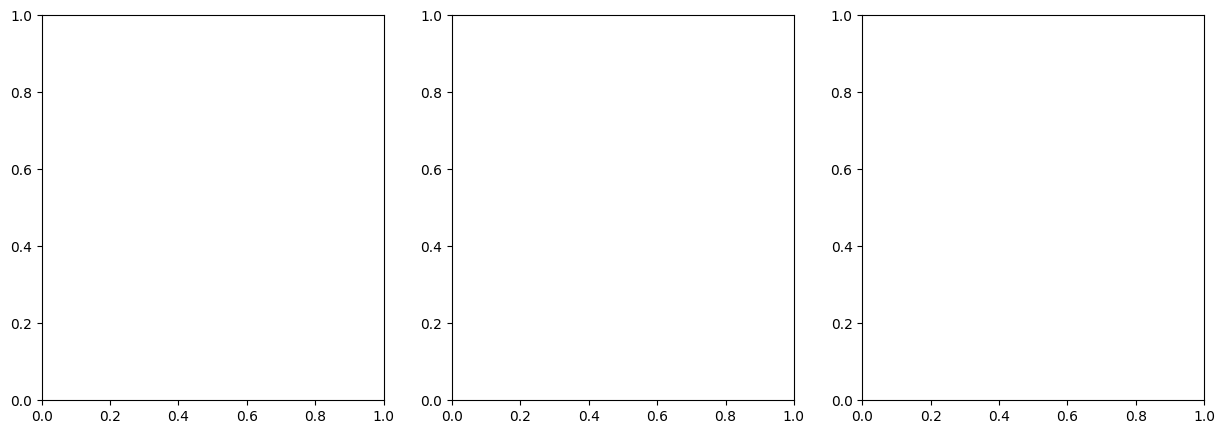

In [17]:
# CELDA 7: PLOT wall_time Gurobi por eje (escala lineal)
# Resultado secundario: confirma que Gurobi certifica óptimo en <1s en todo el rango operativo.

fig, axes_plot = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax_plot, (axis_name, labels) in zip(axes_plot, axis_order.items()):
    sub = df[df["axis"] == axis_name].copy()
    sub["instance_label"] = pd.Categorical(sub["instance_label"], categories=labels, ordered=True)
    agg = (sub.groupby("instance_label", observed=True)["wall_time_s"]
              .agg(["mean", "std"]).reset_index()
              .rename(columns={"mean": "t_mean", "std": "t_std"}))

    ax_plot.errorbar(range(len(agg)), agg["t_mean"], yerr=agg["t_std"].fillna(0),
                     fmt="o-", capsize=4, color="#2C6FAC", label="Gurobi (media ± std)")
    ax_plot.fill_between(range(len(agg)),
                         (agg["t_mean"] - agg["t_std"].fillna(0)).clip(lower=0),
                         agg["t_mean"] + agg["t_std"].fillna(0),
                         alpha=0.15, color="#2C6FAC")
    ax_plot.set_ylim(bottom=0)
    ax_plot.set_xticks(range(len(labels)))
    ax_plot.set_xticklabels(labels, rotation=15)
    ax_plot.set_xlabel("Instancia")
    ax_plot.set_ylabel("Tiempo de pared (s)" if axis_name == "size" else "")
    ax_plot.set_title(f"Eje {axis_name.capitalize()}")
    ax_plot.legend(fontsize=8)
    ax_plot.grid(True, linestyle=":", alpha=0.5)
    sns.despine(ax=ax_plot)

fig.suptitle("Exp 1 — Wall time Gurobi por eje (certifica óptimo en <1s en rango operativo)",
             fontsize=13)
plt.tight_layout()
plot_path = RESULTS_DIR / "exp01_wall_time.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
logger.info("Guardado: %s", plot_path)
logger.info("Exp 1 VISUALIZE completo.")